C:\Users\Nilavra Ghosh\AppData\Local\Temp\ipykernel_1876\1500847542.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)



--- Performance Parameters for Clark Y ---
 alpha       CL     CL/CD  CL^1.5/CD        CM
   0.0 0.225294 18.036506   8.561054 -0.136304
   1.0 0.289728 19.956468  10.741846 -0.151359
   2.0 0.353962 20.735911  12.336769 -0.166347
   3.0 0.417944 20.467385  13.231875 -0.181252
   4.0 0.481619 19.449923  13.498009 -0.196061
   5.0 0.544939 18.249188  13.471548 -0.210758
   6.0 0.607850 17.033290  13.279960 -0.225324
   7.0 0.670303 15.874929  12.997127 -0.239746
   8.0 0.732250 14.779792  12.647305 -0.254009
   9.0 0.793641 13.818794  12.310685 -0.268092
  10.0 0.854429 12.986625  12.004229 -0.281974
  11.0 0.914569 12.254053  11.718931 -0.295641
  12.0 0.974016 11.599848  11.448150 -0.309075
  13.0 1.032725 11.003292  11.181884 -0.322268
  14.0 1.090656 10.422637  10.884826 -0.335225
  15.0 1.147768  9.893358  10.599143 -0.347920


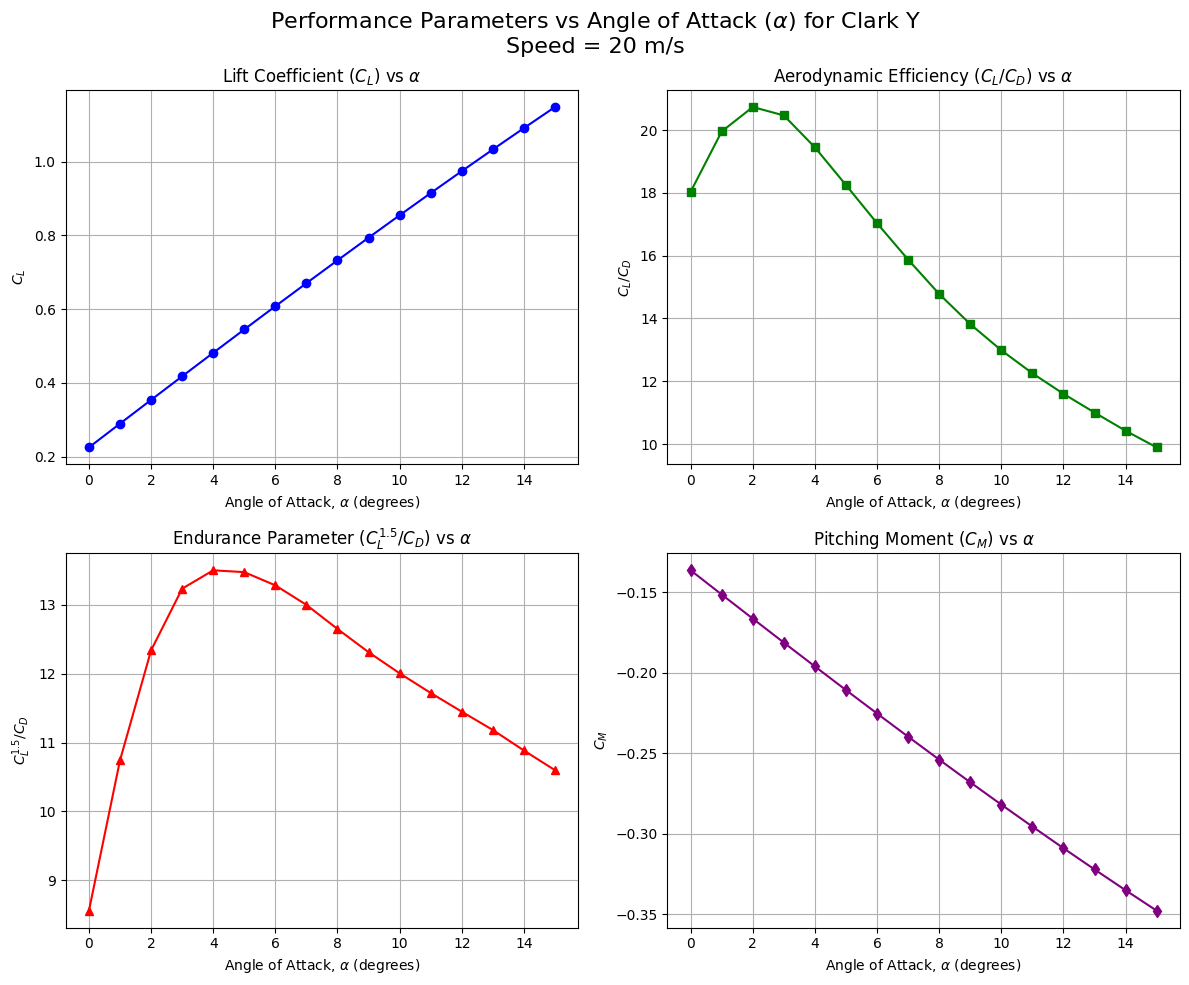

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(2023102006)

def analyze_airfoil_data(file_path, airfoil_name):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
    header_idx = -1
    for i, line in enumerate(lines):
        if 'alpha' in line and 'CL' in line and 'CD' in line:
            header_idx = i
            break
            
    if header_idx == -1:
        raise ValueError(f"Could not find the data table in {file_path}. Check the file format.")

    df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)

    df['CL/CD'] = df['CL'] / df['CD']
    df['CL^1.5/CD'] = (df['CL']**1.5) / df['CD']
    df.rename(columns={'Cm': 'CM'}, inplace=True)

    results_df = df[['alpha', 'CL', 'CL/CD', 'CL^1.5/CD', 'CM']].copy()

    print(f"\n--- Performance Parameters for {airfoil_name} ---")
    print(results_df.to_string(index=False))

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Performance Parameters vs Angle of Attack ($\\alpha$) for {airfoil_name}\nSpeed = 20 m/s', fontsize=16)

    axs[0, 0].plot(results_df['alpha'], results_df['CL'], marker='o', color='b', label='CL')
    axs[0, 0].set_title(r'Lift Coefficient ($C_L$) vs $\alpha$')
    axs[0, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 0].set_ylabel(r'$C_L$')
    axs[0, 0].grid(True)

    axs[0, 1].plot(results_df['alpha'], results_df['CL/CD'], marker='s', color='g', label='CL/CD')
    axs[0, 1].set_title(r'Aerodynamic Efficiency ($C_L/C_D$) vs $\alpha$')
    axs[0, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 1].set_ylabel(r'$C_L / C_D$')
    axs[0, 1].grid(True)

    axs[1, 0].plot(results_df['alpha'], results_df['CL^1.5/CD'], marker='^', color='r', label='CL^1.5/CD')
    axs[1, 0].set_title(r'Endurance Parameter ($C_L^{1.5}/C_D$) vs $\alpha$')
    axs[1, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 0].set_ylabel(r'$C_L^{1.5} / C_D$')
    axs[1, 0].grid(True)

    axs[1, 1].plot(results_df['alpha'], results_df['CM'], marker='d', color='purple', label='CM')
    axs[1, 1].set_title(r'Pitching Moment ($C_M$) vs $\alpha$')
    axs[1, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 1].set_ylabel(r'$C_M$')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

FILE_PATH = 'CLARK Y_T1-20_0 m_s-VLM1.txt'  
AIRFOIL_NAME = 'Clark Y'    

analyze_airfoil_data(FILE_PATH, AIRFOIL_NAME)